# Seams in the WAC_EMP reflectance mosaic

`hillshade`'s texture is WAC_EMP reflectance, mosaicked from ten archive tiles onto each entry's
local grid (`ortho_wac_emp.reproject_wac_emp_reflectance_to_local_grid`). The tiles meet along
three kinds of seam:

- **±60° latitude**: equirectangular tiles meet the polar-stereographic tile of that hemisphere.
- **The equator**: north and south equirectangular tiles meet.
- **0°, 90°, 180°, 270° longitude**: neighboring equirectangular tiles meet, between 60°S and 60°N.

A seam can go wrong in several ways: a coverage gap (`NaN`), a step (the two sides disagree), or a
line (a spike in brightness or texture right at the seam, with both sides otherwise matching).
This notebook renders a synthetic 200 km square centered on every point where three or four tiles
meet (`seam_probes.WAC_EMP_PROBES`), through the same code path the `hillshade` generator uses, and
measures each seam crossing it.

`tests/test_reflectance_seams.py` runs the same probes and checks the same numbers against the same
limits (`seam_probes.wac_emp_thresholds`). When that test fails, this notebook shows why.

In [1]:
from IPython.display import display

from trntest import seam_plotting, seam_probes

SOURCE = "reflectance"
source = seam_probes.SOURCES[SOURCE]
results = seam_probes.run_source(SOURCE)
table = seam_probes.metrics_table(results)
health = seam_probes.probe_health_table(results, source.thresholds)

## Metrics

For each seam, the metrics come from a *seam-normal profile*: pixels binned by signed distance
from the seam (1 px bins, positive to the north or east), away from the probe's other seam.

- `nan_near`: `NaN` pixels within 3 px of the seam. A coverage gap along a seam is a bug.
- `step`: the difference between the two sides, each extrapolated to the seam from a straight
  line fit 6-30 px out, relative to the probe's median reflectance.
- `spike`: the largest deviation of a near-seam bin (within 3 px) from its side's line,
  relative to the median. A bright or dark line shows up here; so does the blended edge of a step.
- `gradient_ratio`: the largest near-seam median gradient magnitude, divided by the reference
  bins'. A line or a texture change raises it even when the mean doesn't move.

Terrain alone moves every one of these. To show by how much, the same metrics are computed on
*control lines*: lines parallel to each seam, 80-320 px away, inside a single tile. The plot shows
them in grey behind each real seam, with the test's pass limit as a short bar.

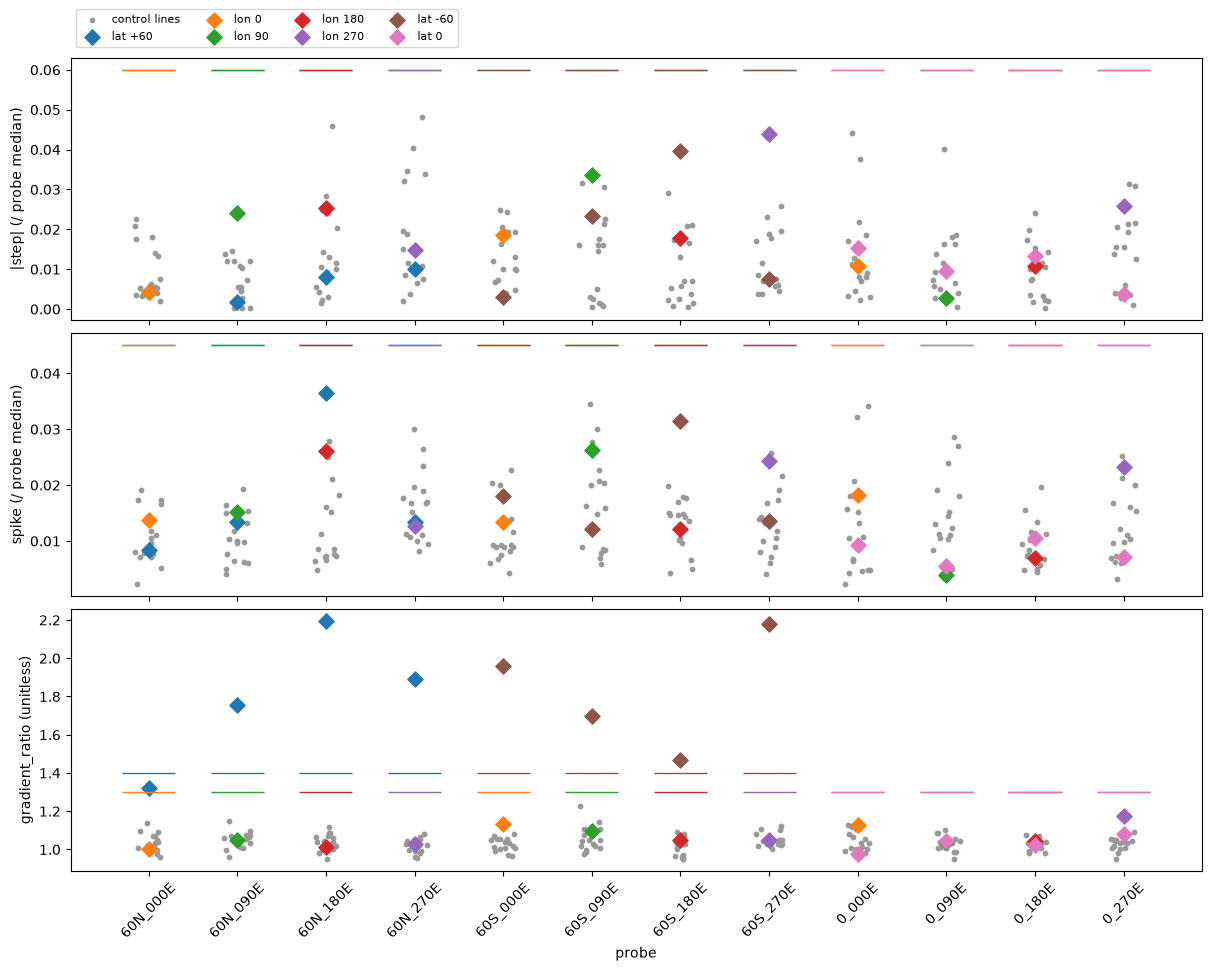

In [2]:
seam_plotting.plot_metrics_vs_controls(table, source.thresholds)

## Health by probe

One row per probe: its worst value of each metric over its seams; `limit_use`, how close its
closest metric is to that metric's limit (1.0 = at the limit; `gradient_ratio` counts from 1), and
which seam and metric that is; and pass/fail, which is what the test checks.

Each probe name links to a report notebook with its renders, profiles and straightened seam
strips. The reports aren't committed: running this notebook writes them under
`output/seam_probes/reflectance/`, so the links only work in a checkout where it has run.

In [3]:
links = seam_probes.report_links(seam_probes.write_probe_reports(SOURCE))
seam_plotting.show_health_table(health, links)

probe,tiles,nan_px,nan_near,max_abs_step,max_spike,max_gradient_ratio,limit_use,limit_use_by,status,failed
60N_000E,3,63,0,0.004,0.014,1.321,0.803,lat +60: gradient_ratio,pass,
60N_090E,3,232,0,0.024,0.015,1.754,1.885,lat +60: gradient_ratio,FAIL,lat +60: gradient_ratio
60N_180E,3,1027,0,0.025,0.037,2.195,2.988,lat +60: gradient_ratio,FAIL,lat +60: gradient_ratio
60N_270E,3,624,0,0.015,0.013,1.892,2.230,lat +60: gradient_ratio,FAIL,lat +60: gradient_ratio
60S_000E,3,838,0,0.019,0.018,1.959,2.397,lat -60: gradient_ratio,FAIL,lat -60: gradient_ratio
60S_090E,3,2,0,0.034,0.026,1.696,1.739,lat -60: gradient_ratio,FAIL,lat -60: gradient_ratio
60S_180E,3,177,0,0.040,0.032,1.467,1.168,lat -60: gradient_ratio,FAIL,lat -60: gradient_ratio
60S_270E,3,750,0,0.044,0.024,2.180,2.949,lat -60: gradient_ratio,FAIL,lat -60: gradient_ratio
0_000E,4,0,0,0.015,0.018,1.128,0.425,lon 0: gradient_ratio,pass,
0_090E,4,0,0,0.009,0.006,1.045,0.158,lat 0: step,pass,


Every seam, for reference:

In [4]:
display(table[~table.control].drop(columns="control").round(4))

,probe,seam,length_px,nan_near,step,spike,gradient_ratio
0,60N_000E,lat +60,1983,0,-0.0042,0.0084,1.3210
1,60N_000E,lon 0,980,0,0.0043,0.0138,1.0024
18,60N_090E,lat +60,1983,0,-0.0017,0.0134,1.7541
19,60N_090E,lon 90,980,0,-0.0241,0.0153,1.0507
36,60N_180E,lat +60,1983,0,0.0082,0.0365,2.1952
37,60N_180E,lon 180,980,0,0.0253,0.0261,1.0144
54,60N_270E,lat +60,1983,0,-0.0101,0.0133,1.8920
55,60N_270E,lon 270,980,0,-0.0149,0.0127,1.0291
72,60S_000E,lat -60,1983,0,-0.0030,0.0181,1.9590
73,60S_000E,lon 0,980,0,0.0185,0.0134,1.1315
